In [2]:
import numpy as np

def doselog(logx,b,c,d,ec50):
    logx=np.asarray(logx, dtype="float")     #x와 e가 이미 로그값,   
    z=b*(logx-ec50)                         #b가 기울기이니까 b가 음수이면 방향이 바뀌나?
    z=np.clip(z, -700.0, 700.0)
    return c+(d-c)/(1+np.exp(z))


#indicator 함수를 생성하는 함수? len, pick 위치?
#logisic+indicator -> dictionary?
#0->1로 증가하는 함수를 딕셔너리 함수에 

Matplotlib is building the font cache; this may take a moment.


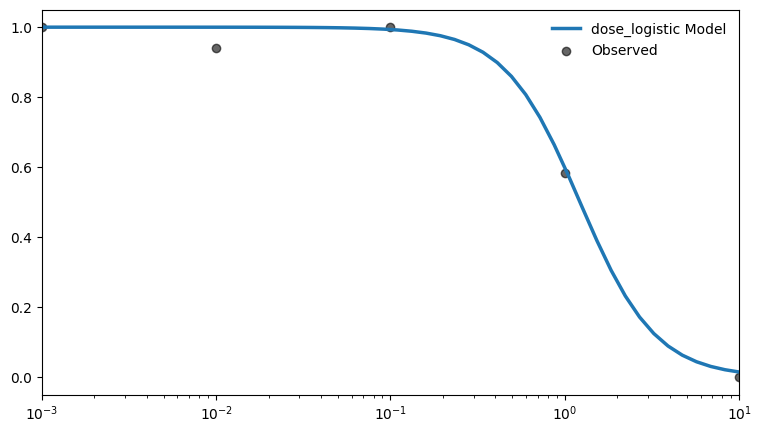

In [3]:
import matplotlib.pyplot as plt
#파라미터 지정
b=2.0
ec50 =0.2   #이미 로그값을 취한 값이 ec50=0.2
c=0.0
d=1.0

logx=np.linspace(np.log(1e-3), np.log(1e1), 50)     #곡선에 사용할 grid(logx는 선형 간격용)
y=doselog(logx,b,c,d,ec50)

dose=np.exp(logx) #플롯은 원래 dose 축을 기준으로..

#시뮬레이션 데이터
np.random.seed(1234)
x_data=np.logspace(-3,1,5)  #관측 dose
y_data=doselog(np.log(x_data), b,c,d,ec50)+np.random.normal(0,0.05, len(x_data))
y_data=np.clip(y_data, 0,1)

#시각화
plt.figure(figsize=(9,5))
plt.plot(dose, y, linewidth=2.5, label="dose_logistic Model")
plt.scatter(x_data, y_data, color="k", alpha=0.6, label="Observed")
plt.xscale("log")
plt.xlim(1e-3, 1e1)
plt.ylim(-0.05, 1.05)
plt.legend(frameon=False)

In [4]:
#딕셔너리 행렬을 생성하는 함수

def doselog_dictionary(logx, b_grid, ec50_grid, c=0.0, d=1.0, normalize=True):
    atoms=[]
    for b in b_grid:   #각 (b, ec50)에 대해서 길이 len(logx)의 basis를 생성후 행으로 쌓음
        for ec50 in ec50_grid:
            v=doselog(logx, b=b, c=c, d=d, ec50=ec50).astype(float) #각 조합 (b, ec50)으로 basis v를 계산
            if normalize:
                n=np.linalg.norm(v)  #정규화 
                if n>0: v=v/n
            atoms.append(v)
    D=np.vstack(atoms)
    return D

#주어진 그리드가 다음과 같을때
logx=np.linspace(np.log(1e-3),np.log(1e1),200)  #샘플
dose=np.exp(logx)
b_grid=[1.0, 2.0, 3.0 ,4.0,5.0]
ec50_grid=[0.1,0.2,0.3,1.0,2.0]

D=doselog_dictionary(logx, b_grid, ec50_grid, c=0.0, d=1.0, normalize=True)
print(D.shape) #(n_atoms, n_features)  n_atioms는 |b_grid수|*|ec50_grid수| +(아직 구현 안함:indicator개수)

print(D)
#예시
np.random.seed(1234)
y_true=doselog(logx, b=2.2, c=0.0, d=1.0,ec50=0.9) #정답 y_true
noise=np.random.normal(0,0.05, size=logx.size)
y_obs= y_true+noise
#테스트용 정답 곡선 파라미터를 지정후 딕셔너리(b, ec50)후보로 y_obs를 근사하는 방법
#그리드에 정확한 값이 없을 수 있으니 스파스 코딩으로 여러 atoms를 조합해 가장 가까운 형태로 근사..?

#sparse코딩
from sklearn.decomposition import SparseCoder
#D=(n_atoms, n_features) 열이 logx그리드 , y_obs는 (n_features)인 1차원 벡터 
coder=SparseCoder(dictionary=D, transform_algorithm="lasso_lars", transform_alpha=0.1)
#규제강도 0.1설정, 1/2||xD-y||^2 +||X||1를 품
coef=coder.transform(y_obs.reshape(1, -1))          #shape: (1, n_atoms)로 배치 한개 입력
#반환값은 선택한 atoms에만 값이고 나머지는 0또는 매우 작은 값
#->어떤 basis를 얼마나 썼는지를 담은것...
y_hat=(coef@D).ravel()                              #재구성(1,n_features)->(n_features,)
#y_hat=xD를 구현 #.ravel()은 배열을 1차원으로 평평하게 하는 함

print(coef)
#coef값에서 0이 아닌값이 딕셔너리 기여값

#플롯
import matplotlib.pyplot as plt
plt.figure(figsize=(9,4))
plt.plot(dose, y_obs, "k.", ms=4, label="Observed")
plt.plot(dose, y_hat, "r-", lw=2, label="Sparse recon")
plt.xscale("log")
plt.xlabel("Dose")
plt.ylabel("Response")
plt.legend()
plt.show()



(25, 200)
[[8.75481407e-02 8.75443917e-02 8.75404654e-02 ... 9.47486999e-03
  9.09079453e-03 8.72055081e-03]
 [8.68468597e-02 8.68434943e-02 8.68399698e-02 ... 1.02697931e-02
  9.85798765e-03 9.46065685e-03]
 [8.61629924e-02 8.61599710e-02 8.61568067e-02 ... 1.11214265e-02
  1.06807283e-02 1.02551088e-02]
 ...
 [8.11345700e-02 8.11345700e-02 8.11345700e-02 ... 5.77592797e-06
  4.58274448e-06 3.63603620e-06]
 [7.73742349e-02 7.73742349e-02 7.73742349e-02 ... 1.81991497e-04
  1.44464011e-04 1.14663371e-04]
 [7.28210018e-02 7.28210018e-02 7.28210018e-02 ... 1.88757130e-02
  1.58235171e-02 1.31446018e-02]]


ModuleNotFoundError: No module named 'sklearn'

In [ ]:
from itertools import product

def dose_dictionary_plot(logx, b_grid, ec50_grid, c=0.0, d=1.0, title="Dictionary matrix"):
    dose = np.exp(logx)
    plt.figure(figsize=(12, 3.4))
    for i, (b, e50) in enumerate(product(b_grid, ec50_grid), start=1):
        basis = doselog(logx, b=b, c=c, d=d, ec50=e50)  
        plt.plot(dose, basis, lw=1.2, alpha=0.9, label=f"b={b}, EC50={e50:.2g}")
    plt.xscale("log"); plt.ylim(-0.02, 1.02)
    plt.ylabel("Basis value"); plt.title(title)
    leg = plt.legend(
        ncol=3, fontsize=8, frameon=False,
        columnspacing=0.8, handlelength=1.2, handletextpad=0.4,
        borderaxespad=0.2, labelspacing=0.25,
        loc="upper left", bbox_to_anchor=(0.01, 0.99)
    )
   #plt.legend(frameon=False, ncol=3) 범례를 크게 할때
dose_dictionary_plot(logx, b_grid, ec50_grid, c=0.0, d=1.0)

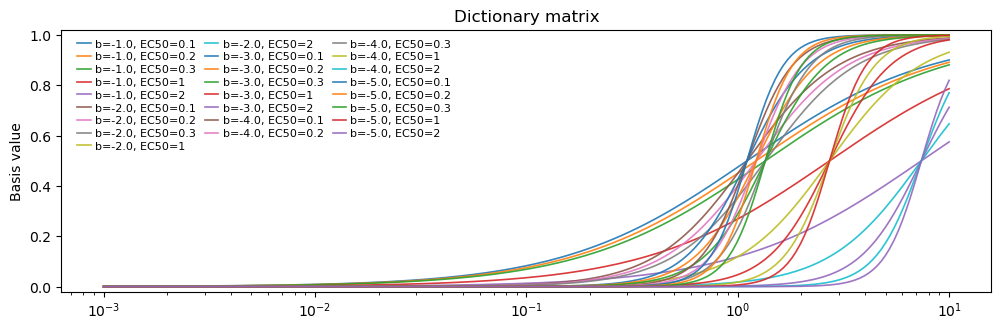

In [5]:
b_grid=[-1.0,-2.0,-3.0,-4.0,-5.0]
ec50_grid=[0.1,0.2,0.3,1.0,2.0]

dose_dictionary_plot(logx, b_grid, ec50_grid, c=0.0, d=1.0)

In [6]:
#indicator 함수?
#갑자기 점프하는 곳을 포착할려면 인디케이터함수를 딕셔너리에 같이 넣어야함..

#def indicator(logx, tau, direction="ge", normalize=True):
    #logx>tau면 direciton은 "ge", logx<tau면 "lt"
#    logx=np.asarray(logx, dtype=float)
#    tau=np.atleast_1d(tau).astype(float)  #항상 array형태를 보장하기 위해 입력값이 스칼라면 자동으로 벡터처럼 표현
#    D=[]
#    D = []
#    if direction=="ge":
#        for t in tau:
#            D.append((logx>=t).astype(float))
#    elif direction == "lt":
#        for t in tau:
#            D.append((logx<t).astype(float))
#    else:
#        raise ValueError("direction must be 'ge' or 'lt'")
#    D=np.vstack(D)
#    if normalize:
#        nrm = np.linalg.norm(D, axis=1, keepdims=True); nrm[nrm==0]=1.0
#        D=D/nrm
#    return D


